In [2]:
!nvidia-smi

Mon Mar 23 19:54:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             34W /   70W |    1193MiB /  15360MiB |     26%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import keras as kr
from keras import layers
import seaborn as sb
import sklearn
import tensorflow as tf
import random as rnd
import math
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sklearn.set_config(transform_output="pandas")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
%cd /content/drive/My Drive/waste-clasifier/

/content/drive/My Drive/waste-clasifier


In [6]:
classes = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

In [7]:
train_csv=pd.read_csv("train/_classes.csv")
train_df=pd.DataFrame(train_csv)
train_ppc_csv=pd.read_csv("train_preprocessed/_classes_preprocessed.csv")
train_ppc_df=pd.DataFrame(train_ppc_csv)
test_csv=pd.read_csv("test/_classes.csv")
test_df=pd.DataFrame(test_csv)
valid_csv=pd.read_csv("valid/_classes.csv")
valid_df=pd.DataFrame(valid_csv)

y_train = train_df[classes].values
y_val = valid_df[classes].values
y_test = test_df[classes].values
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1767 entries, 0 to 1766
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filename   1767 non-null   object
 1   cardboard  1767 non-null   int64 
 2   glass      1767 non-null   int64 
 3   metal      1767 non-null   int64 
 4   paper      1767 non-null   int64 
 5   plastic    1767 non-null   int64 
 6   trash      1767 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 96.8+ KB


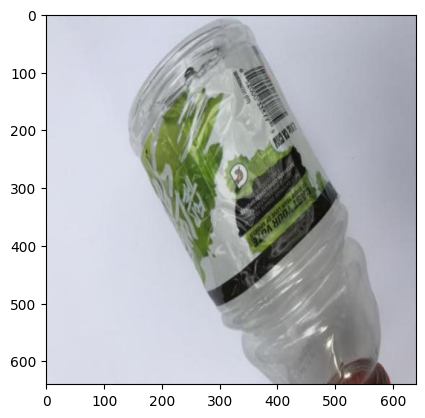

In [8]:
random_idx = rnd.randint(0, len(train_df) - 1)
img_path = os.path.join("train", train_df["filename"][random_idx])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

In [9]:
vis_df=pd.DataFrame({
    "train":train_df[classes].sum(),
    "test":test_df[classes].sum(),
    "valid":valid_df[classes].sum()
})
vis_df

,train,test,valid
cardboard,275,44,84
glass,352,47,102
metal,284,40,85
paper,423,64,107
plastic,340,44,96
trash,93,14,30


<Axes: xlabel='category', ylabel='count'>

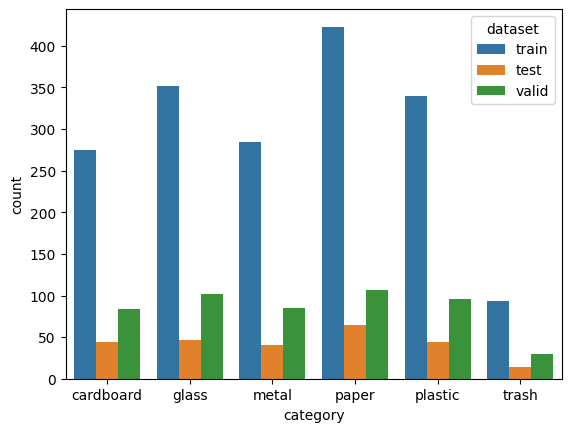

In [9]:
df_plot = vis_df.reset_index().rename(columns={'index': 'category'})
df_melted = df_plot.melt(id_vars='category', var_name='dataset', value_name='count')
sb.barplot(data=df_melted, x='category', y='count', hue='dataset')

In [13]:
datagen = ImageDataGenerator(rescale=1./255)
image_size=640
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="train/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=64,
    class_mode="raw"
)

Found 1767 validated image filenames.


In [14]:
datagen = ImageDataGenerator(rescale=1./255)
image_ppc_size=256
train_ppc_generator = datagen.flow_from_dataframe(
    dataframe=train_ppc_df,
    directory="train_preprocessed/",
    x_col=train_ppc_df.columns[0],
    y_col=classes,
    target_size=(image_ppc_size, image_ppc_size),
    batch_size=128,
    class_mode="raw"
)

Found 14136 validated image filenames.


In [15]:
v_size=256
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory="valid/",
    x_col=valid_df.columns[0],
    y_col=classes,
    target_size=(v_size, v_size),
    batch_size=32,
    class_mode="raw"
)

Found 504 validated image filenames.


In [16]:
t_size=256
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory="test/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(t_size, t_size),
    batch_size=32,
    class_mode="raw"
)

Found 253 validated image filenames.


In [14]:
def augment_image_tf(image, label, orig_size=640, target_size=256):
    """
    Funkcja, która będzie aplikowana do każdego elementu (zdjęcie, etykieta) 
    w Twoim tf.data.Dataset. Wykonuje się na CPU.
    """
    # 1. Losowanie kąta dla pojedynczego zdjęcia
    angle = tf.random.uniform(shape=[], minval=-math.pi, maxval=math.pi)
    
    # 2. Rotacja (używamy tfa, jeśli jest dostępne, lub budujemy prostą macierz jak poprzednio)
    # W potoku tf.data możemy spokojnie korzystać z wbudowanej biblioteki tfa
    # Jeśli nie masz TensorFlow Addons, użyjemy wbudowanego w tf mechanizmu 
    
    # Krok A: Obliczenie parametrów macierzy 
    alpha = -angle
    cos_a = tf.cos(alpha)
    sin_a = tf.sin(alpha)
    
    # Wektor transformacji (odpowiadający obrotowi o -angle wokół środka)
    cx = tf.cast(orig_size, tf.float32) / 2.0
    cy = tf.cast(orig_size, tf.float32) / 2.0
    
    a0 = cos_a
    a1 = -sin_a
    a2 = cx - cx * cos_a + cy * sin_a
    
    b0 = sin_a
    b1 = cos_a
    b2 = cy - cx * sin_a - cy * cos_a
    
    transform = tf.stack([a0, a1, a2, b0, b1, b2, 0.0, 0.0])
    
    # Krok B: Aplikacja transformacji przy użyciu funkcji CPU
    # W przestrzeni tf.data to zadziała poprawnie bez kompilatora XLA
    rotated_img = tf.raw_ops.ImageProjectiveTransformV3(
            images=tf.expand_dims(image, 0), # Operacja wymaga batcha, więc dajemy 1
            transforms=tf.expand_dims(transform, 0),
            output_shape=tf.constant([orig_size, orig_size], dtype=tf.int32),
            fill_value=0.0,
            interpolation='BILINEAR',
            fill_mode='CONSTANT'
    )[0] # Zabieramy z powrotem wymiar batcha

    # 3. Dynamiczne cięcie (jak wcześniej)
    safe_s = float(orig_size) / (tf.abs(cos_a) + tf.abs(sin_a))
    safe_s_int = tf.cast(tf.math.floor(safe_s), tf.int32)
    
    offset = (orig_size - safe_s_int) // 2
    
    cropped_img = tf.image.crop_to_bounding_box(
        rotated_img, offset, offset, safe_s_int, safe_s_int
    )

    # 4. Skalowanie na docelowy 256x256
    final_img = tf.image.resize(cropped_img, [target_size, target_size])
    
    return final_img, label

In [15]:
# Przykład tworzenia tf.data.Dataset z Twojego DataFrame

def load_and_preprocess(filepath, label):
    # Wczytanie pliku
    img_raw = tf.io.read_file(filepath)
    img_tensor = tf.image.decode_jpeg(img_raw, channels=3)
    img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
    # Wstępne skalowanie do dużej rozdzielczości (640x640)
    img_tensor = tf.image.resize(img_tensor, [640, 640])
    return img_tensor, label

# 1. Inicjalizacja bazowego zbioru ze ścieżek i etykiet
# Zastąp 'filenames_list' swoimi danymi, np. train_df['filename'].values
# Zastąp 'labels_array' swoimi zakodowanymi etykietami (One-Hot)
train_dataset = tf.data.Dataset.from_tensor_slices(("train/"+train_df["filename"], y_train))

# 2. Wczytanie obrazów do pamięci
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = train_dataset.cache()
# 3. Dodanie naszej augmentacji TYLKO do zbioru treningowego
train_dataset = train_dataset.map(augment_image_tf, num_parallel_calls=tf.data.AUTOTUNE)

# 4. Standardowe operacje dla batcha (tasowanie, paczkowanie, prefetch dla wydajności)
BATCH_SIZE = 32
train_dataset = train_dataset.shuffle(buffer_size=1000)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

In [17]:
from sklearn.utils.class_weight import compute_class_weight

one_hot_labels = train_df[classes].values 
print(one_hot_labels)

train_classes_int = np.argmax(one_hot_labels, axis=1)
print(train_classes_int)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes_int),
    y=train_classes_int
)

class_weights_dict = dict(enumerate([x for x in class_weights_array]))
print(sum(class_weights_dict))

print("Wyliczone wagi klas:", class_weights_dict)

[[0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 ...
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]
[3 3 3 ... 0 0 0]
15
Wyliczone wagi klas: {0: np.float64(1.0709090909090908), 1: np.float64(0.8366477272727273), 2: np.float64(1.0369718309859155), 3: np.float64(0.6962174940898345), 4: np.float64(0.8661764705882353), 5: np.float64(3.1666666666666665)}


In [17]:
class DynamicRotationCropResizing(layers.Layer):
    def __init__(self, target_size=(256, 256), original_size=(640, 640), **kwargs):
        super().__init__(**kwargs)
        self.target_height = target_size[0]
        self.target_width = target_size[1]
        self.orig_S = float(original_size[0])

    def call(self, inputs, training=None):
        inputs = tf.cast(inputs, tf.float32)
        
        # W trybie walidacji/inferencji robimy tylko prosty resize
        if not training:
            resized = tf.image.resize(inputs, [self.target_height, self.target_width])
            return resized

        batch_size = tf.shape(inputs)[0]
        # Losujemy kąty od -180 do 180 stopni (w radianach)
        angles = tf.random.uniform(shape=[batch_size], minval=-np.pi, maxval=np.pi)

        # Odwracamy kąt do przeliczeń macierzy (kierunek mapowania z docelowego na źródłowy)
        alpha = -angles 
        
        cos_a = tf.cos(alpha)
        sin_a = tf.sin(alpha)
        
        # Przygotowanie stałych
        orig_S_tensor = tf.constant(self.orig_S, dtype=tf.float32)
        target_H = tf.constant(self.target_height, dtype=tf.float32)
        target_W = tf.constant(self.target_width, dtype=tf.float32)

        # 1. Obliczamy bezpieczny bok s(theta) dla uniknięcia czarnych rogów
        abs_cos = tf.abs(tf.cos(angles))
        abs_sin = tf.abs(tf.sin(angles))
        safe_S = orig_S_tensor / (abs_sin + abs_cos)
        
        # 2. Obliczamy współczynnik skalowania 'k' (zmniejszenie s do 256)
        k = safe_S / target_H
        
        # 3. Środki obrazów
        ctx = target_W / 2.0
        cty = target_H / 2.0
        csx = orig_S_tensor / 2.0
        csy = orig_S_tensor / 2.0
        
        # 4. Parametry macierzy transformacji 3x3 spłaszczone do wektora dla każdego obrazka
        a0 = k * cos_a
        a1 = -k * sin_a
        a2 = -k * cos_a * ctx + k * sin_a * cty + csx
        
        b0 = k * sin_a
        b1 = k * cos_a
        b2 = -k * sin_a * ctx - k * cos_a * cty + csy
        
        zeros = tf.zeros_like(angles)
        
        # Składamy wszystko w tensor o kształcie (batch, 8)
        transforms = tf.stack([a0, a1, a2, b0, b1, b2, zeros, zeros], axis=1)
        
        # 5. WYKONANIE TRANSFORMACJI W JEDNYM KROKU (Brak dynamicznych wymiarów!)
        output = tf.raw_ops.ImageProjectiveTransformV3(
            images=inputs,
            transforms=transforms,
            output_shape=tf.constant([self.target_height, self.target_width], dtype=tf.int32),
            fill_value=tf.zeros([], dtype=inputs.dtype),
            interpolation='BILINEAR',
            fill_mode='CONSTANT'
        )
        
        # Ręcznie informujemy Keras o statycznym kształcie, co jest wymagane dla modeli Sequential
        output.set_shape([inputs.shape[0], self.target_height, self.target_width, inputs.shape[3]])
        
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "target_size": (self.target_height, self.target_width),
            "original_size": (int(self.orig_S), int(self.orig_S)),
        })
        return config

In [20]:
micro_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(640, 640, 3)),
    DynamicRotationCropResizing(target_size=(256, 256), original_size=(640, 640))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [21]:
def visualize_random_augmentation(df, image_dir="."):
    """
    df: Twój pandas DataFrame
    image_dir: Ścieżka do folderu z obrazkami (jeśli w 'filename' są tylko nazwy plików)
    """
    # Losujemy jeden wiersz
    random_row = df.sample(1).iloc[0]
    img_path = os.path.join(image_dir, random_row['filename'])
    
    # Wczytujemy i dekodujemy obrazek
    img_raw = tf.io.read_file(img_path)
    img_tensor = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    
    # Upewniamy się, że to float32 i skalujemy do 640x640 (jeśli oryginał ma inny wymiar)
    img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
    img_tensor = tf.image.resize(img_tensor, [640, 640])
    
    # Dodajemy wymiar batcha: (640, 640, 3) -> (1, 640, 640, 3)
    img_batch = tf.expand_dims(img_tensor, axis=0)
    
    # Przepuszczamy przez mikro model z wymuszeniem trybu uczenia (training=True)
    augmented_batch = micro_model(img_batch, training=True)
    
    # Usuwamy wymiar batcha do wizualizacji
    augmented_img = augmented_batch[0]
    
    # Wyświetlamy wyniki
    plt.figure(figsize=(12, 6))
    
    # Oryginał
    plt.subplot(1, 2, 1)
    plt.title(f"Oryginał (640x640)\nPlik: {random_row['filename']}")
    plt.imshow(img_tensor)
    plt.axis('off')
    
    # Zaugmentowany
    plt.subplot(1, 2, 2)
    plt.title("Po Augmentacji (256x256)\nRotacja + Dynamic Crop")
    # tf.image.resize może wyrzucić wartości poza 0-1, więc dla pewności przycinamy
    plt.imshow(tf.clip_by_value(augmented_img, 0.0, 1.0)) 
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

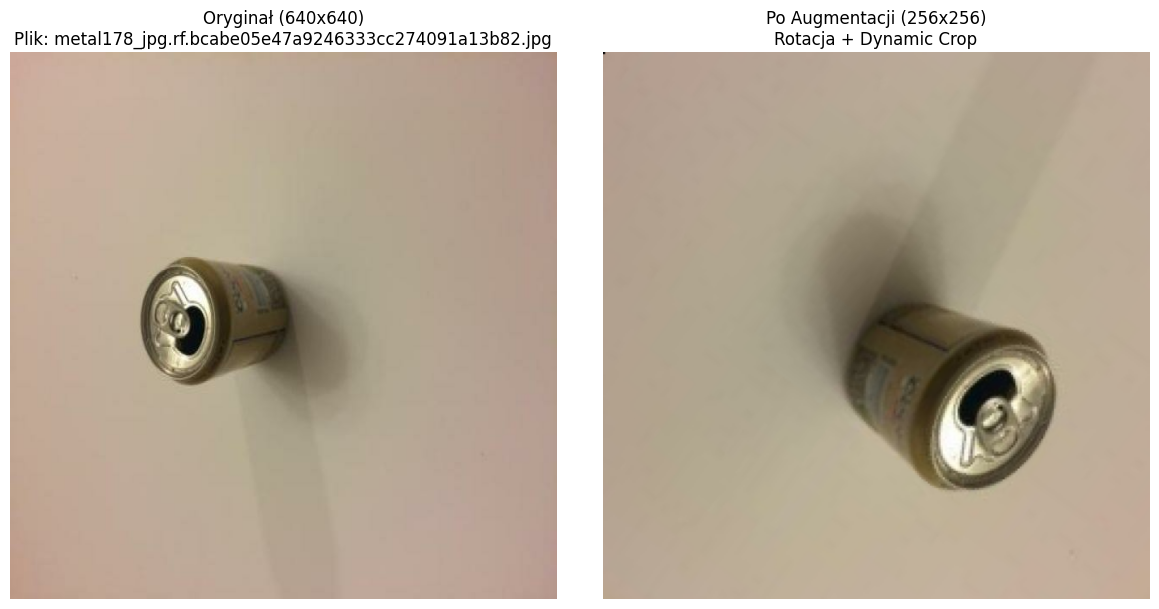

In [22]:
visualize_random_augmentation(train_df,"train")

In [23]:
def load_and_preprocess(filepath, label):
    # Wczytanie pliku
    img_raw = tf.io.read_file(filepath)
    img_tensor = tf.image.decode_jpeg(img_raw, channels=3)
    img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
    # Wstępne skalowanie do dużej rozdzielczości (640x640)
    img_tensor = tf.image.resize(img_tensor, [640, 640])
    return img_tensor, label

In [18]:
conv_dense=8
image_size=640
target_size=256
model=kr.Sequential(
    [
        layers.Input((target_size,target_size,3)),

        #DynamicRotationCropResizing(target_size=(target_size, target_size), original_size=(image_size, image_size)),

        layers.Conv2D(conv_dense, 7, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((2*conv_dense), 5, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((3*conv_dense), 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((4*conv_dense), 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
        
        #layers.AveragePooling2D(pool_size=(2, 2), strides=None, padding="valid"),
        layers.Flatten(),
        
        layers.Dropout(0.5),

        #layers.Dense(100,activation="softplus"),
        layers.Dense(100,activation="tanh"),

        layers.Dropout(0.3),
        
        layers.Dense(6, activation="softmax")
    ]
)

model.build()
model.summary()
#kr.utils.plot_model(model, show_shapes=True)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 8)    │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 24)     │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       819,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 835,050 (3.19 MB)

 Trainable params: 834,890 (3.18 MB)

 Non-trainable params: 160 (640.00 B)

In [ ]:
"""
def make_model(input_shape, conv_dense=64, conv_num=3, num_classes=2):
    inputs = kr.Input(shape=input_shape)

    # Entry block
    #x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(conv_dense, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual
    size=conv_dense
    for i in range(1,conv_num):
        size*=2
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes
    
    x = layers.Flatten()(x)
    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(num_classes, activation=None)(x)
    return kr.Model(inputs, outputs)


model = make_model(input_shape=(image_size,image_size,3), num_classes=6)
kr.utils.plot_model(model, show_shapes=True)
"""

'\ndef make_model(input_shape, conv_dense=64, conv_num=3, num_classes=2):\n    inputs = kr.Input(shape=input_shape)\n\n    # Entry block\n    #x = layers.Rescaling(1.0 / 255)(inputs)\n    x = layers.Conv2D(conv_dense, 3, strides=2, padding="same")(inputs)\n    x = layers.BatchNormalization()(x)\n    x = layers.Activation("relu")(x)\n\n    previous_block_activation = x  # Set aside residual\n    size=conv_dense\n    for i in range(1,conv_num):\n        size*=2\n        x = layers.Activation("relu")(x)\n        x = layers.SeparableConv2D(size, 3, padding="same")(x)\n        x = layers.BatchNormalization()(x)\n\n        x = layers.Activation("relu")(x)\n        x = layers.SeparableConv2D(size, 3, padding="same")(x)\n        x = layers.BatchNormalization()(x)\n\n        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)\n\n        # Project residual\n        residual = layers.Conv2D(size, 1, strides=2, padding="same")(\n            previous_block_activation\n        )\n        x = la

In [11]:
def generate_offline_dataset(csv_path, source_dir, dest_dir):
    # Wczytujemy oryginalny plik CSV
    df = pd.read_csv(csv_path)
    
    # Tworzymy folder docelowy, jeśli nie istnieje
    os.makedirs(dest_dir, exist_ok=True)
    
    new_rows = []
    angles = [0, 45, 90, 135, 180, 225, 270, 315]
    
    S = 360
    target_size = 256
    
    # Środek obrazu do rotacji
    center = (S / 2, S / 2)
    
    print(f"Rozpoczynam generowanie zdjęć. Do przetworzenia: {len(df)} plików bazowych...")
    
    for index, row in df.iterrows():
        orig_filename = row['filename']
        img_path = os.path.join(source_dir, orig_filename)
        
        # Wczytanie obrazu (OpenCV wczytuje w formacie BGR, co jest ok, 
        # bo imwrite też oczekuje BGR)
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"Ostrzeżenie: Nie znaleziono pliku {img_path}. Pomijam.")
            continue
            
        # Upewniamy się, że obraz wejściowy ma na pewno 360x360
        if img.shape[:2] != (S, S):
            img = cv2.resize(img, (S, S), interpolation=cv2.INTER_AREA)
            
        for angle in angles:
            # 1. Obliczamy bezpieczny rozmiar boku s(theta)
            rad = math.radians(angle)
            sin_a = abs(math.sin(rad))
            cos_a = abs(math.cos(rad))
            
            # Bezpieczny rozmiar kwadratu wewnętrznego
            safe_s = int(S / (sin_a + cos_a))
            
            # 2. Rotacja
            # Przy 0 stopniach pomijamy transformację dla oszczędności czasu
            if angle != 0:
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                rotated = cv2.warpAffine(
                    img, M, (S, S), 
                    flags=cv2.INTER_LINEAR, 
                    borderMode=cv2.BORDER_CONSTANT, 
                    borderValue=(0,0,0) # Czarne rogi do odcięcia
                )
            else:
                rotated = img
                
            # 3. Dynamiczne Kadrowanie ze środka
            offset = (S - safe_s) // 2
            cropped = rotated[offset:offset+safe_s, offset:offset+safe_s]
            
            # 4. Skalowanie na docelowy 256x256
            # Ciekawostka matematyczna: dla 45 stopni safe_s wynosi ~254. 
            # Skalowanie 254 -> 256 jest bezstratne dla oka.
            final_img = cv2.resize(cropped, (target_size, target_size), interpolation=cv2.INTER_CUBIC)
            
            # 5. Zapis pliku
            name, ext = os.path.splitext(orig_filename)
            new_filename = f"{name}_rot{angle}{ext}"
            new_filepath = os.path.join(dest_dir, new_filename)
            
            cv2.imwrite(new_filepath, final_img)
            
            # 6. Dodanie informacji do nowej tabeli
            new_row = row.copy()
            new_row['filename'] = new_filename
            new_rows.append(new_row)
            
        # Prosty wskaźnik postępu
        if (index + 1) % 200 == 0:
            print(f"Przetworzono {index + 1} / {len(df)} zdjęć bazowych...")

    # Zapis nowego pliku CSV
    new_df = pd.DataFrame(new_rows)
    new_csv_path = os.path.join(dest_dir, "_classes_preprocessed.csv")
    new_df.to_csv(new_csv_path, index=False)
    
    print(f"\nGotowe! Zapisano łącznie {len(new_df)} obrazów w folderze '{dest_dir}'.")
    print(f"Nowy plik z etykietami: {new_csv_path}")

In [12]:
generate_offline_dataset("train/_classes.csv","train","train_preprocessed")

Rozpoczynam generowanie zdjęć. Do przetworzenia: 1767 plików bazowych...
Przetworzono 200 / 1767 zdjęć bazowych...
Przetworzono 400 / 1767 zdjęć bazowych...
Przetworzono 600 / 1767 zdjęć bazowych...
Przetworzono 800 / 1767 zdjęć bazowych...
Przetworzono 1000 / 1767 zdjęć bazowych...
Przetworzono 1200 / 1767 zdjęć bazowych...
Przetworzono 1400 / 1767 zdjęć bazowych...
Przetworzono 1600 / 1767 zdjęć bazowych...

Gotowe! Zapisano łącznie 14136 obrazów w folderze 'train_preprocessed'.
Nowy plik z etykietami: train_preprocessed/_classes_preprocessed.csv


In [45]:
model_load = kr.models.load_model(
    "sml_model50.keras"
    #custom_objects={"full_attention_block": full_attention_block
                    #,"loss":get_sparse_weighted_loss
                    #}
)

In [20]:
epochs = 50
Adam = kr.optimizers.Adam(learning_rate=0.001)
r_lr=kr.callbacks.ReduceLROnPlateau(patience=2, monitor="val_accuracy",factor=0.7)
e_s=kr.callbacks.EarlyStopping(patience=10, monitor="val_accuracy")
model.compile(optimizer=Adam,loss="categorical_crossentropy",metrics =['accuracy','recall','precision'])
model.fit(
    train_ppc_generator,
    epochs=epochs,
    callbacks=[r_lr,e_s],
    validation_data=valid_generator,
    class_weight=class_weights_dict
)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.4285 - loss: 1.5389 - precision: 0.5084 - recall: 0.3120 - val_accuracy: 0.2123 - val_loss: 3.4210 - val_precision: 0.2123 - val_recall: 0.2123 - learning_rate: 0.0010
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 102s 920ms/step - accuracy: 0.5224 - loss: 1.2634 - precision: 0.6070 - recall: 0.4024 - val_accuracy: 0.3016 - val_loss: 2.1229 - val_precision: 0.3570 - val_recall: 0.2897 - learning_rate: 0.0010
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 99s 892ms/step - accuracy: 0.5848 - loss: 1.1100 - precision: 0.6678 - recall: 0.4697 - val_accuracy: 0.2798 - val_loss: 1.6802 - val_precision: 0.2874 - val_recall: 0.1984 - learning_rate: 0.0010
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 100s 896ms/step - accuracy: 0.6065 - loss: 1.0303 - precision: 0.6914 - recall: 0.4954 - val_accuracy: 0.3611 - val_loss: 1.6442 - val_precision: 0.4377 - val_recall: 0.2718 - learning_rate: 0.0010
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 83s 749ms/st

In [23]:
model.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 66s 8s/step - accuracy: 0.7352 - loss: 0.7235 - precision: 0.8128 - recall: 0.7036


[0.7234910726547241,
 0.7351778745651245,
 0.7035573124885559,
 0.8127853870391846]

In [22]:
model.save('goat_model50.keras')

In [ ]:

"""
goat_model_50 | accuracy: 0.7352 - loss: 0.7235 - precision: 0.8128 - recall: 0.7036
too_long_model42 | accuracy: 0.5929 - loss: 1.1717 - precision: 0.7365 - recall: 0.4308
next3_model43 | accuracy: 0.6482 - loss: 1.0186 - precision: 0.7182 - recall: 0.6245
next2_model34 | accuracy: 0.6640 - loss: 1.0755 - precision: 0.7257 - recall: 0.6482
next_model38 | accuracy: 0.6719 - loss: 1.0829 - precision: 0.7124 - recall: 0.6364
thing_model38 | accuracy: 0.6561 - loss: 1.0464 - precision: 0.7182 - recall: 0.6245
gigant3_model42 | accuracy: 0.6719 - loss: 0.9546 - precision: 0.7212 - recall: 0.5929 - 256
gigant2_model38 | accuracy: 0.6087 - loss: 1.0791 - precision: 0.6837 - recall: 0.5296 - 256
gigant_model47 | accuracy: 0.6443 - loss: 0.9469 - precision: 0.7311 - recall: 0.6126 - 256
ballanced2_model47 | accuracy: 0.6522 - loss: 1.0356 - precision: 0.7436 - recall: 0.5731 - 256
ballanced_model34 | accuracy: 0.6561 - loss: 1.0261 - precision: 0.7346 - recall: 0.6126 - 128
overfitted_model23 | accuracy: 0.6245 - loss: 1.3682 - precision: 0.6565 - recall: 0.5968 - 128
mikro_model50 | accuracy: 0.6877 - loss: 0.9676 - precision: 0.7451 - recall: 0.6008 - 128
mikro_model67 | accuracy: 0.6759 - loss: 0.9928 - precision: 0.7299 - recall: 0.6087 - 128
good_model1 | accuracy: 0.2530 - loss: 2.6561 - precision: 0.2530 - recall: 0.2530 - 128
good_model2 | accuracy: 0.3439 - loss: 2.1603 - precision: 0.3798 - recall: 0.3123 - 128
bigger_good_model50 | accuracy: 0.6877 - loss: 0.9277 - precision: 0.7273 - recall: 0.6324 - 128
cnn_mini1 | accuracy: 0.2530 - loss: 1.7233 - precision: 0.0000e+00 - recall: 0.0000e+00 - 128
cnn_test1 | accuracy: 0.1779 - loss: 10.2570 - precision: 0.2003 - recall: 0.6008 - 128
cnn_test2 | accuracy: 0.1581 - loss: 6.6893 - precision: 0.2055 - recall: 0.4111 - 128
idk_model50 | accuracy: 0.5850 - loss: 1.1330 - precision: 0.7634 - recall: 0.3953 - 128
sml_model46 | accuracy: 0.6522 - loss: 0.9800 - precision: 0.7225 - recall: 0.5968 - 128
sml_model50 | accuracy: 0.6245 - loss: 1.0281 - precision: 0.7020 - recall: 0.5494 - 128






"""